<a href="https://colab.research.google.com/github/vivek-bhushan/vivek-bhushan-IITM-WEEK9/blob/main/Jupyter%20Notebook_Week%209_Graded%20Mini%20Project_%5BVivek-Bhushan%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.7 MB/s eta 0:00:00
Shape: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN    

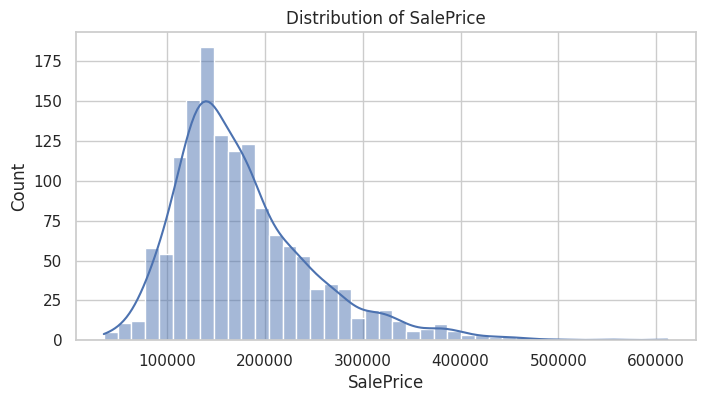

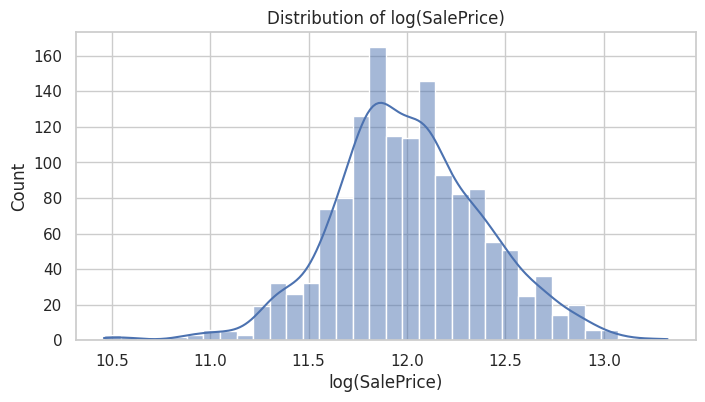

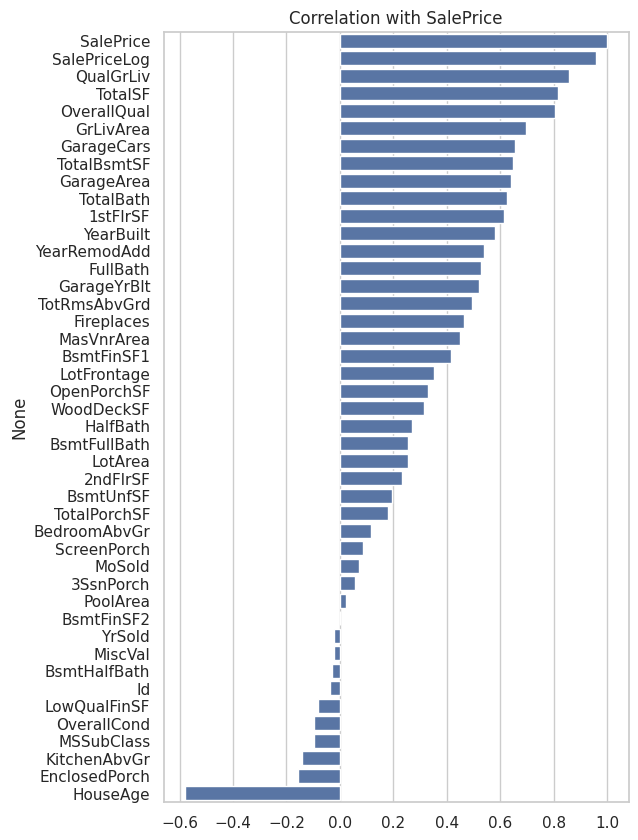

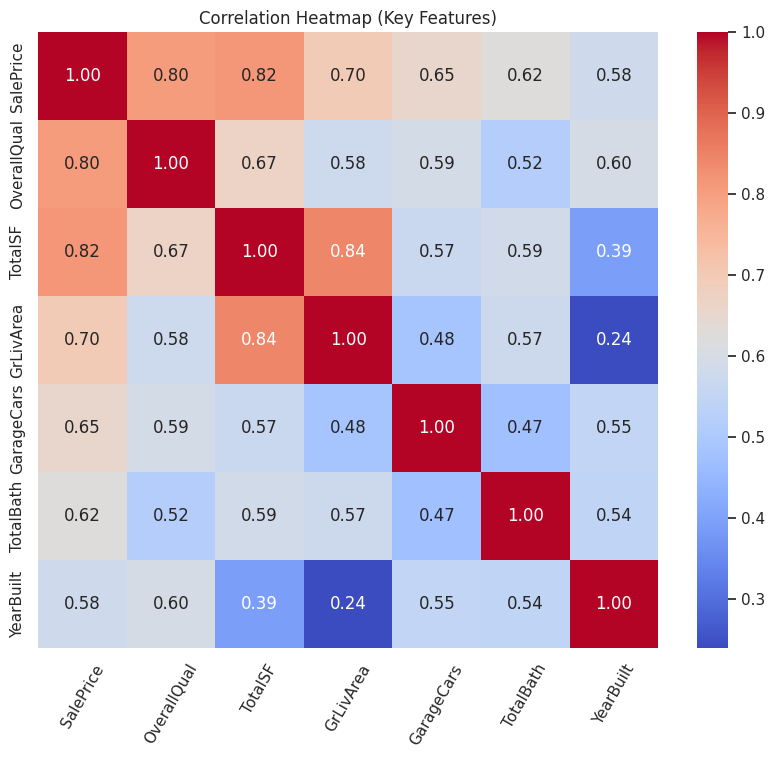

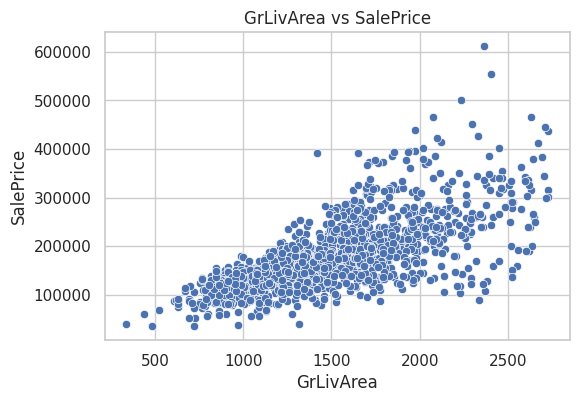

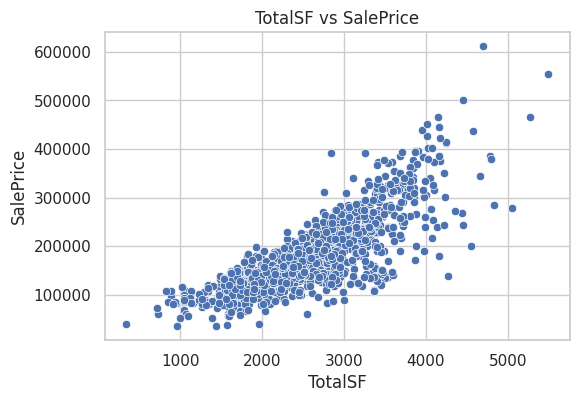

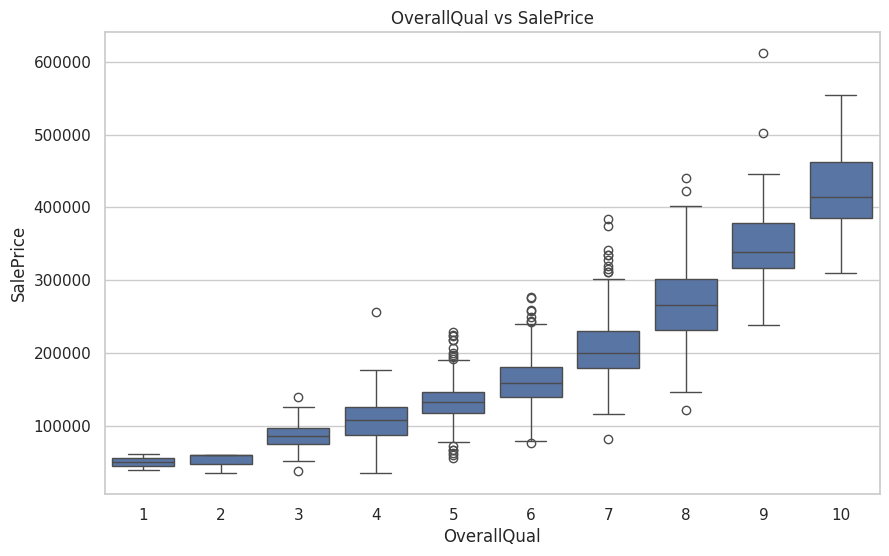

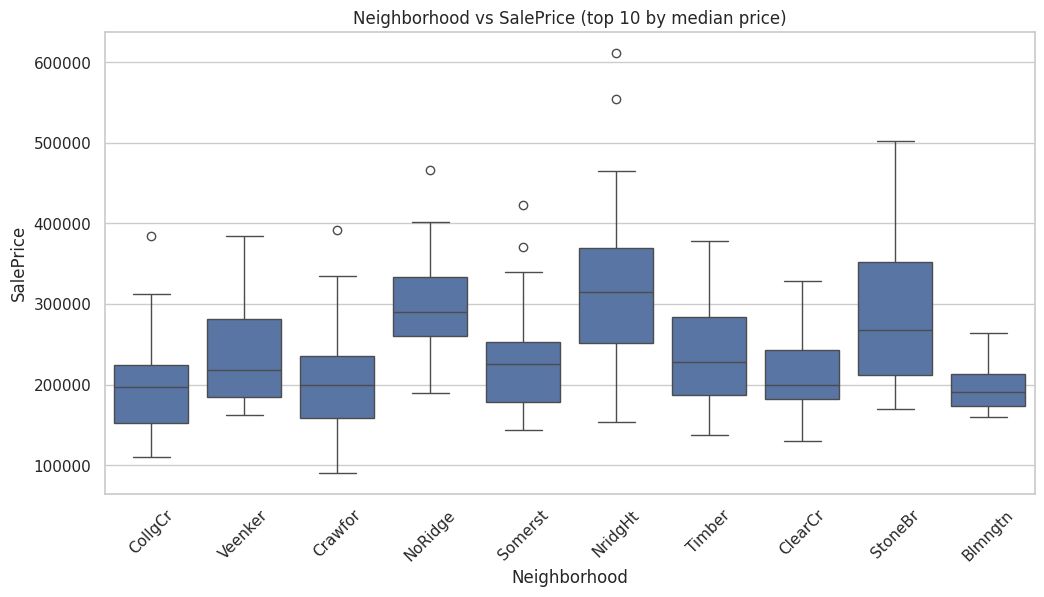


XGBoost
  RMSE (log):    0.11645414968686062
  MAE  (log):    0.07871317385141106
  R^2  (log):    0.9040946336667673
  RMSE (price):  19005.570180259892
  MAE  (price):  12996.756173513986
  R^2  (price):  0.9240184555616573
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002607 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3953
[LightGBM] [Info] Number of data points in the train set: 1143, number of used features: 205
[LightGBM] [Info] Start training from score 12.007860


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



LightGBM
  RMSE (log):    0.12709504879620437
  MAE  (log):    0.08453799229235723
  R^2  (log):    0.8857673542380547
  RMSE (price):  21625.08163895048
  MAE  (price):  14410.49878759878
  R^2  (price):  0.9016301924299672

CatBoost
  RMSE (log):    0.10897176447584231
  MAE  (log):    0.07201744848030077
  R^2  (log):    0.9160228875392215
  RMSE (price):  18121.839554940798
  MAE  (price):  12236.736997346328
  R^2  (price):  0.9309202316716818

Model performance summary:
      Model  RMSE_log   MAE_log    R2_log    RMSE_price     MAE_price  \
0   XGBoost  0.116454  0.078713  0.904095  19005.570180  12996.756174   
1  LightGBM  0.127095  0.084538  0.885767  21625.081639  14410.498788   
2  CatBoost  0.108972  0.072017  0.916023  18121.839555  12236.736997   

   R2_price  
0  0.924018  
1  0.901630  
2  0.930920  


,Model,RMSE_log,MAE_log,R2_log,RMSE_price,MAE_price,R2_price
0,XGBoost,0.116454,0.078713,0.904095,19005.570180,12996.756174,0.924018
1,LightGBM,0.127095,0.084538,0.885767,21625.081639,14410.498788,0.901630
2,CatBoost,0.108972,0.072017,0.916023,18121.839555,12236.736997,0.930920


In [1]:
import sys
!pip install xgboost lightgbm catboost

# =========================
# Week 9 Graded Mini Project
# House Price Prediction - Full Pipeline
# =========================

# ---- Imports ----
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# For nicer plots
sns.set(style="whitegrid", context="notebook")

# ---- 1. Load data ----
file_path = "/content/Week 9_Graded Mini Project_Dataset_houseprice.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print(df.head())

target_col = "SalePrice"

# ---- 2. Basic cleaning & outlier handling ----
# (a) Remove outliers based on GrLivArea using IQR rule
def remove_outliers_iqr(df, col, k=1.5):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

df = remove_outliers_iqr(df, "GrLivArea", k=1.5)
print("Shape after outlier removal:", df.shape)

# ---- 3. Feature engineering ----
df_fe = df.copy()

# Total finished square footage (above + below ground)
df_fe["TotalSF"] = (
    df_fe["TotalBsmtSF"] +
    df_fe["1stFlrSF"] +
    df_fe["2ndFlrSF"]
)

# Total bathrooms (full + half; basement + above grade)
df_fe["TotalBath"] = (
    df_fe["FullBath"] + 0.5 * df_fe["HalfBath"] +
    df_fe["BsmtFullBath"] + 0.5 * df_fe["BsmtHalfBath"]
)

# Quality * living area interaction
df_fe["QualGrLiv"] = df_fe["OverallQual"] * df_fe["GrLivArea"]

# Total porch area
df_fe["TotalPorchSF"] = (
    df_fe["OpenPorchSF"] +
    df_fe["EnclosedPorch"] +
    df_fe["3SsnPorch"] +
    df_fe["ScreenPorch"]
)

# House age and bins
df_fe["HouseAge"] = df_fe["YrSold"] - df_fe["YearBuilt"]
df_fe["HouseAgeBin"] = pd.cut(
    df_fe["HouseAge"],
    bins=[0, 10, 30, 60, 200],
    labels=["0-10", "11-30", "31-60", "60+"]
)

# GrLivArea bins (quartiles)
df_fe["GrLivAreaBin"] = pd.qcut(
    df_fe["GrLivArea"],
    q=4,
    labels=["Small", "Medium", "Large", "VeryLarge"]
)

# ---- 4. Define target and features ----
y = np.log1p(df_fe[target_col])  # log-target
X = df_fe.drop(columns=[target_col, "Id"], errors="ignore")

# Identify column types
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()
print("Number of numeric columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))

# ---- 5. Preprocessing: missing values + encoding + scaling ----
# Categorical: missing => "None" (facility not available)
# Numeric: missing => 0

numeric_imputer = SimpleImputer(strategy="constant", fill_value=0)
categorical_imputer = SimpleImputer(strategy="constant", fill_value="None")

numeric_transformer = Pipeline(steps=[
    ("imputer", numeric_imputer),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", categorical_imputer),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

# ---- 6. Train/validation split ----
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, "Valid shape:", X_valid.shape)

# ---- 7. Exploratory Data Analysis (EDA) ----
# 7.1 Distribution of SalePrice
plt.figure(figsize=(8, 4))
sns.histplot(df_fe["SalePrice"], kde=True)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.show()

# 7.2 Distribution of log(SalePrice)
df_fe["SalePriceLog"] = np.log1p(df_fe["SalePrice"])
plt.figure(figsize=(8, 4))
sns.histplot(df_fe["SalePriceLog"], kde=True)
plt.title("Distribution of log(SalePrice)")
plt.xlabel("log(SalePrice)")
plt.show()

# 7.3 Correlation with SalePrice (numeric features)
num_features = df_fe.select_dtypes(exclude=["object", "category"]).columns
corr = df_fe[num_features].corr()["SalePrice"].sort_values(ascending=False)

plt.figure(figsize=(6, 10))
sns.barplot(x=corr.values, y=corr.index)
plt.title("Correlation with SalePrice")
plt.show()

# Heatmap of Key Features
key_features = ['SalePrice','OverallQual','TotalSF','GrLivArea','GarageCars','TotalBath','YearBuilt']
plt.figure(figsize=(10, 8))
sns.heatmap(df_fe[key_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Key Features)')
plt.xticks(rotation=60)
plt.show()

# 7.4 Scatter plots for key variables
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_fe, x="GrLivArea", y="SalePrice")
plt.title("GrLivArea vs SalePrice")
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_fe, x="TotalSF", y="SalePrice")
plt.title("TotalSF vs SalePrice")
plt.show()

# 7.5 Boxplots for categorical vs SalePrice
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_fe, x="OverallQual", y="SalePrice")
plt.title("OverallQual vs SalePrice")
plt.show()

plt.figure(figsize=(12, 6))
top_neigh = (df_fe.groupby("Neighborhood")["SalePrice"]
             .median()
             .sort_values(ascending=False)
             .head(10)
             .index)
sns.boxplot(data=df_fe[df_fe["Neighborhood"].isin(top_neigh)],
            x="Neighborhood", y="SalePrice")
plt.xticks(rotation=45)
plt.title("Neighborhood vs SalePrice (top 10 by median price)")
plt.show()

# ---- 8. Model training & evaluation ----

def evaluate_model(name, pipeline, X_train, y_train, X_valid, y_valid):
    pipeline.fit(X_train, y_train)
    y_pred_log = pipeline.predict(X_valid)

    rmse_log = np.sqrt(mean_squared_error(y_valid, y_pred_log))
    mae_log = mean_absolute_error(y_valid, y_pred_log)
    r2_log = r2_score(y_valid, y_pred_log)

    # Convert back to price scale
    y_valid_price = np.expm1(y_valid)
    y_pred_price = np.expm1(y_pred_log)

    rmse_price = np.sqrt(mean_squared_error(y_valid_price, y_pred_price))
    mae_price = mean_absolute_error(y_valid_price, y_pred_price)
    r2_price = r2_score(y_valid_price, y_pred_price)

    print(f"\n{name}")
    print("  RMSE (log):   ", rmse_log)
    print("  MAE  (log):   ", mae_log)
    print("  R^2  (log):   ", r2_log)
    print("  RMSE (price): ", rmse_price)
    print("  MAE  (price): ", mae_price)
    print("  R^2  (price): ", r2_price)

    return {
        "Model": name,
        "RMSE_log": rmse_log,
        "MAE_log": mae_log,
        "R2_log": r2_log,
        "RMSE_price": rmse_price,
        "MAE_price": mae_price,
        "R2_price": r2_price
    }

results = []

# 8.1 XGBoost
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb_model)
])

results.append(evaluate_model("XGBoost", xgb_pipeline,
                              X_train, y_train, X_valid, y_valid))


# 8.2 LightGBM
lgbm_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", lgbm_model)
])

results.append(evaluate_model("LightGBM", lgbm_pipeline,
                              X_train, y_train, X_valid, y_valid))


# 8.3 CatBoost
cat_model = CatBoostRegressor(
    depth=6,
    learning_rate=0.05,
    n_estimators=1000,
    loss_function="RMSE",
    random_state=42,
    verbose=False
)

cat_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", cat_model)
])

results.append(evaluate_model("CatBoost", cat_pipeline,
                              X_train, y_train, X_valid, y_valid))

# ---- 9. Summary table ----
results_df = pd.DataFrame(results)
print("\nModel performance summary:")
print(results_df)
display(results_df)